<a href="https://colab.research.google.com/github/Yanaantonyuk/sales-analytics-project/blob/main/notebooks/Portfolio_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# adding Bigquery to the notebook
! pip install google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
import pandas as pd

auth.authenticate_user()

client = bigquery.Client(project="data-analytics-mate")

query = """
WITH orders_base AS (
  SELECT
    o.ga_session_id,
    o.item_id
  FROM `DA.order` o
),

session_context AS (
  SELECT
    ob.ga_session_id,
    ob.item_id,
    s.date AS order_date,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.name AS traffic_name,
    sp.medium AS traffic_medium,
    sp.channel AS traffic_channel
  FROM orders_base ob
  LEFT JOIN `DA.session` s
    ON ob.ga_session_id = s.ga_session_id
  LEFT JOIN `DA.session_params` sp
    ON ob.ga_session_id = sp.ga_session_id
),

user_context AS (
  SELECT
    ob.ga_session_id,
    acs.account_id,
    a.is_verified,
    a.is_unsubscribed
  FROM orders_base ob
  LEFT JOIN `DA.account_session` acs
    ON ob.ga_session_id = acs.ga_session_id
  LEFT JOIN `DA.account` a
    ON acs.account_id = a.id
),

product_context AS (
  SELECT
    p.item_id,
    p.category,
    p.name,
    p.price,
    p.short_description
  FROM `DA.product` p
),

final_dataset AS (
  SELECT
    sc.order_date AS order_date,
    ob.ga_session_id AS ga_session_id,
    sc.continent,
    sc.country,
    sc.device,
    sc.browser,
    sc.mobile_model_name,
    sc.operating_system,
    sc.language,
    CONCAT(sc.traffic_name, ' / ', sc.traffic_medium) AS traffic_source_info,
    sc.traffic_channel,
    uc.account_id AS account_id,
    uc.is_verified,
    uc.is_unsubscribed,
    p.category,
    p.name AS product_name,
    p.price,
    p.short_description
  FROM orders_base ob
  LEFT JOIN session_context sc
    ON ob.ga_session_id = sc.ga_session_id AND ob.item_id = sc.item_id
  LEFT JOIN user_context uc
    ON ob.ga_session_id = uc.ga_session_id
  LEFT JOIN product_context p
    ON ob.item_id = p.item_id
)

SELECT
  order_date,
  ga_session_id,
  continent,
  country,
  device,
  browser,
  mobile_model_name,
  operating_system,
  language,
  traffic_source_info,
  traffic_channel,
  account_id,
  is_verified,
  is_unsubscribed,
  category,
  product_name,
  price,
  short_description
FROM final_dataset;
"""

# Request fulfilment
query_job = client.query(query)  # Request SQL- fulfilment
results = query_job.result()
# Converting results to DataFrame
df = results.to_dataframe()

# Displaying the result
df.head()

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source_info,traffic_channel,account_id,is_verified,is_unsubscribed,category,product_name,price,short_description
0,2020-11-06,7799937037,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,(referral) / referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,2020-11-10,4020421879,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(direct) / (none),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,2020-11-24,6717382496,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(referral) / referral,Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2020-11-26,2093497337,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(direct) / (none),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,2020-12-03,9506718330,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,(referral) / referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


Short description of the obtained dataset


In [37]:
import pandas as pd

# Make sure order_date is datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# 1) Total columns
print("Total columns:", df.shape[1])

# 2) Numeric / categorical / datetime columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()
datetime_cols = df.select_dtypes(include="datetime").columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols + datetime_cols]

print("Numeric columns count:", len(numeric_cols))
print("Numeric columns:", numeric_cols)

print("Datetime columns count:", len(datetime_cols))
print("Datetime columns:", datetime_cols)

print("Categorical columns count:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

# 3) Unique sessions
print("Unique sessions (ga_session_id):", df["ga_session_id"].nunique())

# 4) Date period
print("Date range from:", df["order_date"].min(), "to:", df["order_date"].max())

# 5) Missing values
missing_by_col = df.isna().sum()
print("Missing values (total):", missing_by_col.sum())
print("Columns with missing values:", (missing_by_col > 0).sum())

print("\nTop 5 columns with missing values:")
print(missing_by_col.sort_values(ascending=False).head(5))

# 6) Where missing values are biggest (percent)
missing_percent = (df.isna().mean() * 100).round(2)
print("\nTop 5 columns by missing percent (%):")
print(missing_percent.sort_values(ascending=False).head(5))

# 7) Extra simple checks (useful for your report)
print("\nRegistered users rows (account_id is not null):", df["account_id"].notna().sum())
print("Not registered rows (account_id is null):", df["account_id"].isna().sum())

print("\nPrice check:")
print("Min price:", df["price"].min())
print("Max price:", df["price"].max())
print("Price <= 0 rows:", (df["price"] <= 0).sum())





Total columns: 18
Numeric columns count: 5
Numeric columns: ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']
Datetime columns count: 1
Datetime columns: ['order_date']
Categorical columns count: 12
Categorical columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source_info', 'traffic_channel', 'category', 'product_name', 'short_description']
Unique sessions (ga_session_id): 33538
Date range from: 2020-11-01 00:00:00 to: 2021-01-27 00:00:00
Missing values (total): 103278
Columns with missing values: 4

Top 5 columns with missing values:
is_unsubscribed    30757
is_verified        30757
account_id         30757
language           11007
ga_session_id          0
dtype: int64

Top 5 columns by missing percent (%):
is_unsubscribed    91.71
is_verified        91.71
account_id         91.71
language           32.82
ga_session_id       0.00
dtype: float64

Registered users rows (account_id is not null): 2

This dataset is built at the order-line level: each row represents a product purchased within a specific session. It includes session context (date, country/continent, device, browser and language), traffic information (source/medium and channel), user registration details (account ID, email verification, unsubscribe status), and product attributes (category, name, price and short description).
I checked the basic structure of the dataset (number of columns and data types), the time period covered, and the number of unique sessions. I also reviewed missing values to understand which fields are incomplete and why (for example, account-related fields can be empty because many users are not registered). Finally, I ran a simple price sanity check to make sure there are no unexpected values such as zero or negative prices.

**Dataset overview**

**Structure**

Total columns: 18
Numeric columns (5): ga_session_id, account_id, is_verified, is_unsubscribed, price
Datetime columns (1): order_date
Categorical columns (12): continent, country, device, browser, mobile_model_name, operating_system, language, traffic_source_info, traffic_channel, category, product_name, short_description

**Size and time coverage**

Unique sessions: 33,538 (ga_session_id)
Date range: 2020-11-01 to 2021-01-27

**Missing values**

Total missing values: 103,278 across 4 columns
Columns with most missing values:
account_id: 30,757 missing (91.71%)
is_verified: 30,757 missing (91.71%)
is_unsubscribed: 30,757 missing (91.71%)
language: 11,007 missing (32.82%)

**Why these missing values happen**

account_id, is_verified, is_unsubscribed are missing because most sessions/orders come from non-registered users. Only 2,781 rows are linked to a registered account, while 30,757 rows belong to guests (no account ID), so account-related fields cannot be filled.
language is missing because browser language is not available for some sessions in session_params (tracking/data capture is incomplete for that field).

**Price sanity check**

Min price: 3.0
Max price: 9,585.0
Invalid prices (≤ 0): 0 rows

**Extra note (useful for later analysis)**

Because account_id is missing for most rows, any analysis about verification or unsubscribes should be done only on registered users (filter where account_id is not null), otherwise the percentages will be misleading.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Global style (no grey grid)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

def navy_gradient(n, start="#6EC6FF", end="#123A63"):
    """
    Returns n colours (gradient from light blue to navy).
    """
    c1 = np.array(mcolors.to_rgb(start))
    c2 = np.array(mcolors.to_rgb(end))
    return [mcolors.to_hex(c1 + (c2 - c1) * i / max(n - 1, 1)) for i in range(n)]

def plot_bar_gradient(series, title, xlabel, ylabel, top_n=10):
    """
    Bar chart with navy gradient:
    largest = navy, smallest = light blue.
    """
    s = series.head(top_n)
    colors = navy_gradient(len(s))[::-1]  # reverse so biggest is navy

    plt.figure()
    plt.bar(s.index.astype(str), s.values, color=colors)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_donut(series, title, top_n=6):
    """
    Donut chart with navy gradient:
    largest slice = navy, smallest slice = light blue.
    """
    s = series.sort_values(ascending=False).head(top_n)
    colors = navy_gradient(len(s))[::-1]  # reverse so biggest is navy

    plt.figure(figsize=(7, 6))
    plt.pie(
        s.values,
        labels=s.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        wedgeprops={"width": 0.45},
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_lines(df_plot, title, xlabel, ylabel):
    """
    Multi-line chart in the same palette (no grid).
    """
    line_colors = navy_gradient(df_plot.shape[1])[::-1]

    plt.figure()
    for i, col in enumerate(df_plot.columns):
        plt.plot(df_plot.index, df_plot[col], label=col, color=line_colors[i], linewidth=2)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

Top 3 continents by total sales:
continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: sales, dtype: float64


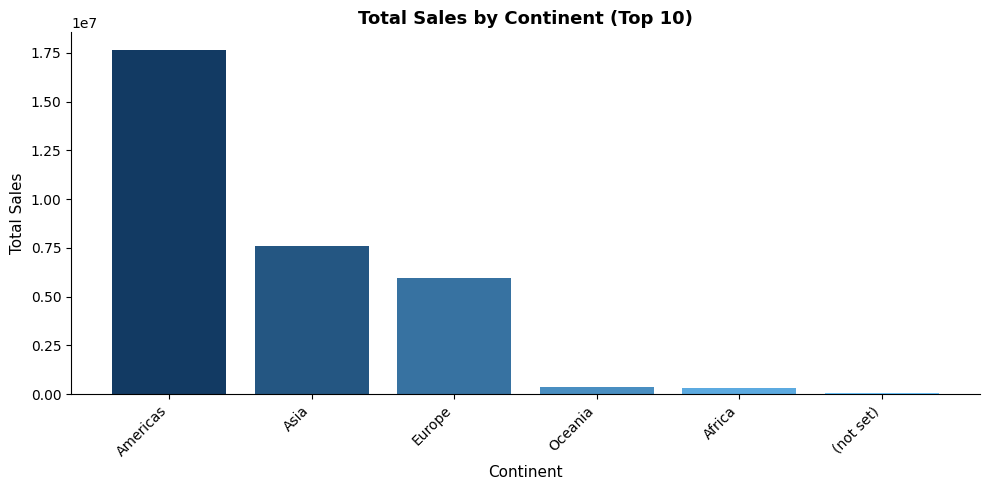

In [39]:
# This cell creates a simple sales metric for analysis (revenue per row).
df["sales"] = df["price"]

# This cell shows the top 3 continents by total sales (sum of price).
sales_by_continent = (
    df.groupby("continent")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("Top 3 continents by total sales:")
print(sales_by_continent.head(3))

plot_bar_gradient(
    sales_by_continent,
    "Total Sales by Continent (Top 10)",
    "Continent",
    "Total Sales",
    top_n=10
)


Top 5 countries by total sales:
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: sales, dtype: float64


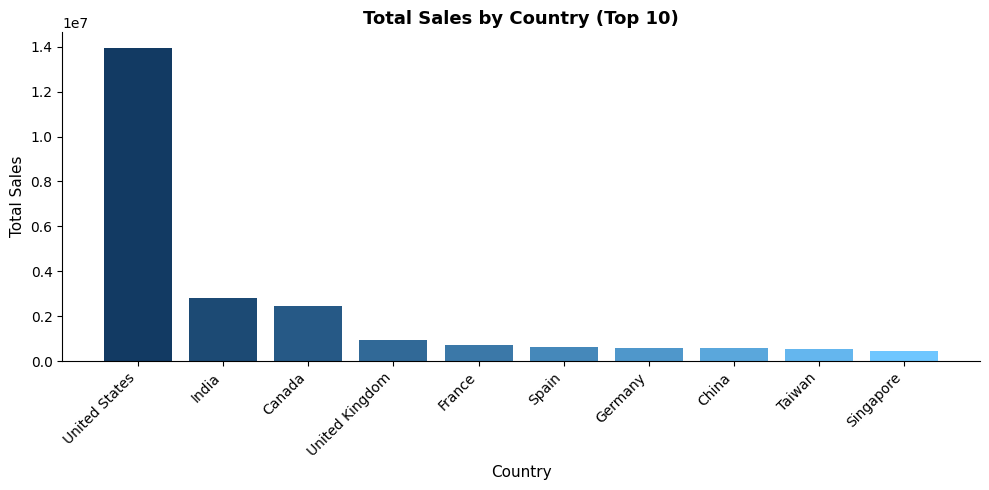

In [40]:
# This cell shows the top 5 countries by total sales and visualises the top 10.
sales_by_country = (
    df.groupby("country")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\nTop 5 countries by total sales:")
print(sales_by_country.head(5))

plot_bar_gradient(
    sales_by_country,
    "Total Sales by Country (Top 10)",
    "Country",
    "Total Sales",
    top_n=10
)


Top 3 continents by number of sessions (proxy for orders):
continent
Americas    18553
Asia         7950
Europe       6261
Name: ga_session_id, dtype: int64


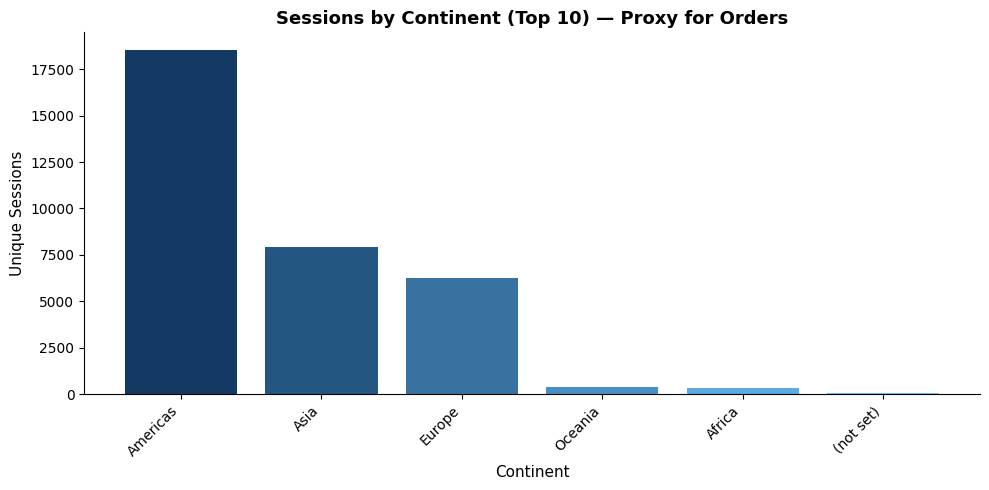

In [41]:
# This cell uses unique sessions as a proxy for order count (order_id is not available).
sessions_by_continent = (
    df.groupby("continent")["ga_session_id"]
      .nunique()
      .sort_values(ascending=False)
)

print("\nTop 3 continents by number of sessions (proxy for orders):")
print(sessions_by_continent.head(3))

plot_bar_gradient(
    sessions_by_continent,
    "Sessions by Continent (Top 10) — Proxy for Orders",
    "Continent",
    "Unique Sessions",
    top_n=10
)



Top 5 countries by number of sessions (proxy for orders):
country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Name: ga_session_id, dtype: int64


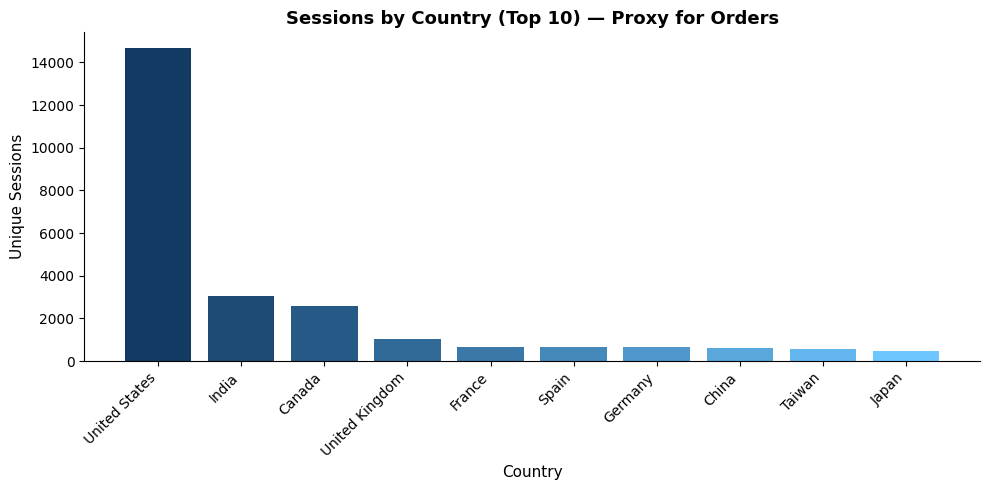

In [7]:
# This cell shows the top 5 countries by number of sessions (proxy for orders) and visualises the top 10.
sessions_by_country = (
    df.groupby("country")["ga_session_id"]
      .nunique()
      .sort_values(ascending=False)
)

print("\nTop 5 countries by number of sessions (proxy for orders):")
print(sessions_by_country.head(5))

plot_bar_gradient(
    sessions_by_country,
    "Sessions by Country (Top 10) — Proxy for Orders",
    "Country",
    "Unique Sessions",
    top_n=10
)



Top 10 categories by total sales:
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: sales, dtype: float64


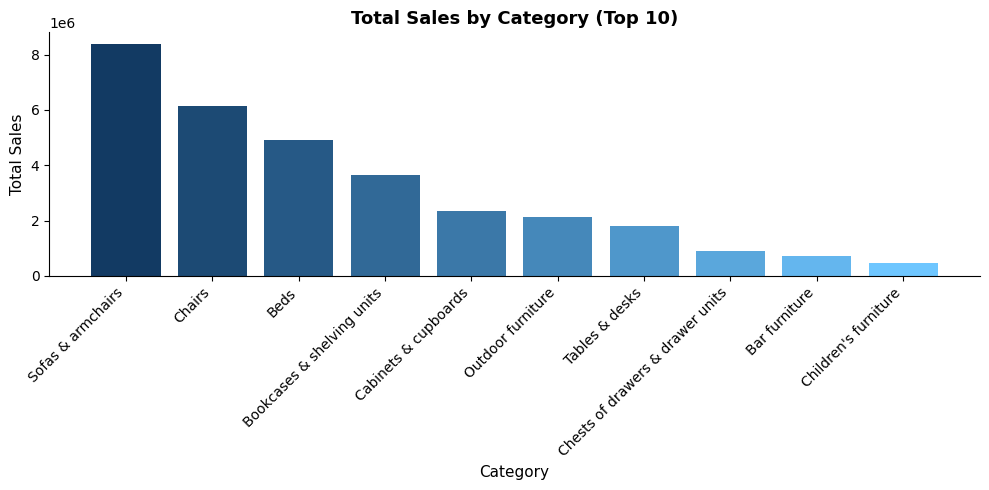

In [8]:
# This cell identifies the top 10 product categories by total sales.
sales_by_category = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\nTop 10 categories by total sales:")
print(sales_by_category.head(10))

plot_bar_gradient(
    sales_by_category,
    "Total Sales by Category (Top 10)",
    "Category",
    "Total Sales",
    top_n=10
)




Top country by total sales: United States
Total sales in top country: 13943553.9

Global Top 10 categories by sales:
category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: sales, dtype: float64


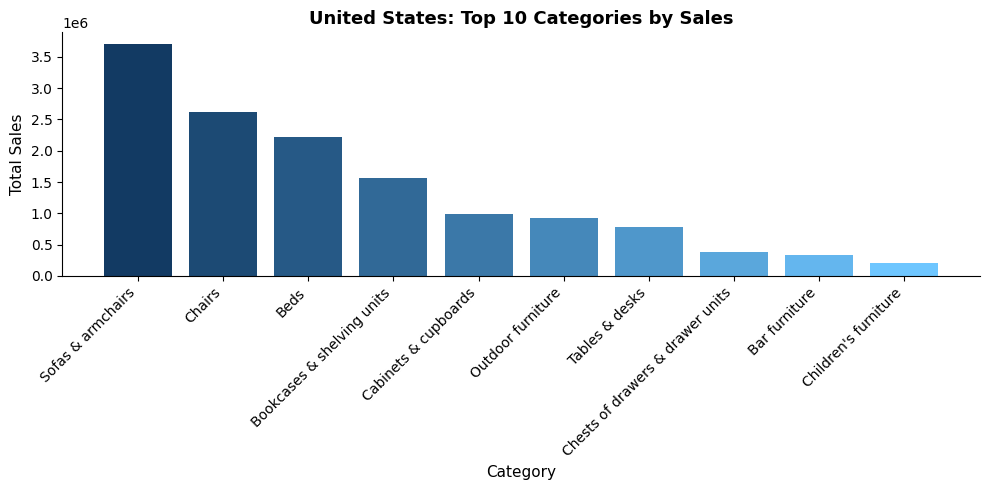

In [9]:
# This cell finds the single country with the highest total sales (used for a deep-dive comparison).
top_country = sales_by_country.index[0]
top_country_sales = sales_by_country.iloc[0]

print("\nTop country by total sales:", top_country)
print("Total sales in top country:", top_country_sales)


# This cell compares global top categories vs top categories in the highest-sales country.
df_top_country = df[df["country"] == top_country]

top_categories_top_country = (
    df_top_country.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_categories_global = sales_by_category.head(10)

print("\nGlobal Top 10 categories by sales:")
print(top_categories_global)

plot_bar_gradient(
    top_categories_top_country,
    f"{top_country}: Top 10 Categories by Sales",
    "Category",
    "Total Sales",
    top_n=10
)

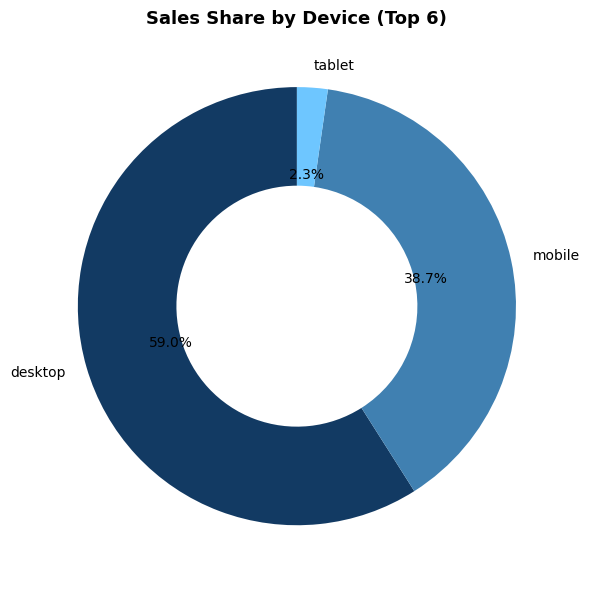

In [10]:
# This donut shows sales share by device (Top 6 devices).
device_sales = df.groupby("device")["sales"].sum()
plot_donut(device_sales, "Sales Share by Device (Top 6)", top_n=6)

Top devices by sales share (%):
device
desktop    59.00
mobile     38.73
tablet      2.26
Name: sales, dtype: float64


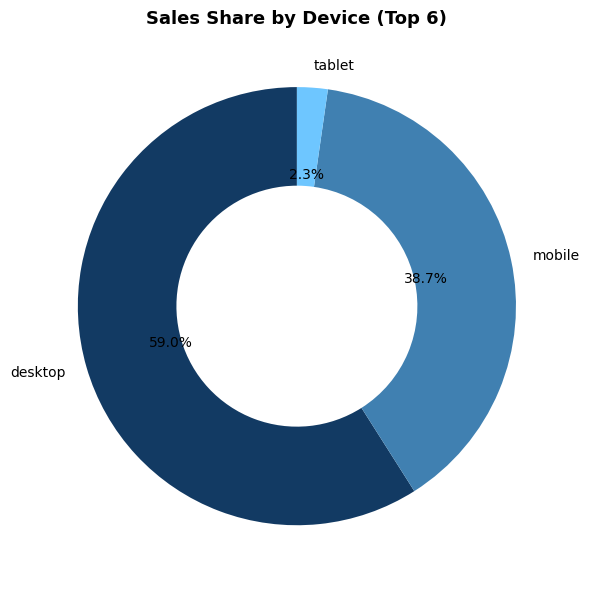

In [11]:
# This cell shows the share of total sales by device (percentage).
total_sales = df["sales"].sum()

device_sales = df.groupby("device")["sales"].sum().sort_values(ascending=False)
device_share_pct = (device_sales / total_sales * 100).round(2)

print("Top devices by sales share (%):")
print(device_share_pct.head(10))

plot_donut(device_sales, "Sales Share by Device (Top 6)", top_n=6)

Top 10 mobile models by sales share (%):
mobile_model_name
Chrome        27.84
<Other>       20.44
Safari        20.30
iPhone        20.08
ChromeBook     5.73
Edge           2.18
iPad           1.40
Firefox        1.32
Pixel 4 XL     0.37
Pixel 3        0.34
Name: sales, dtype: float64


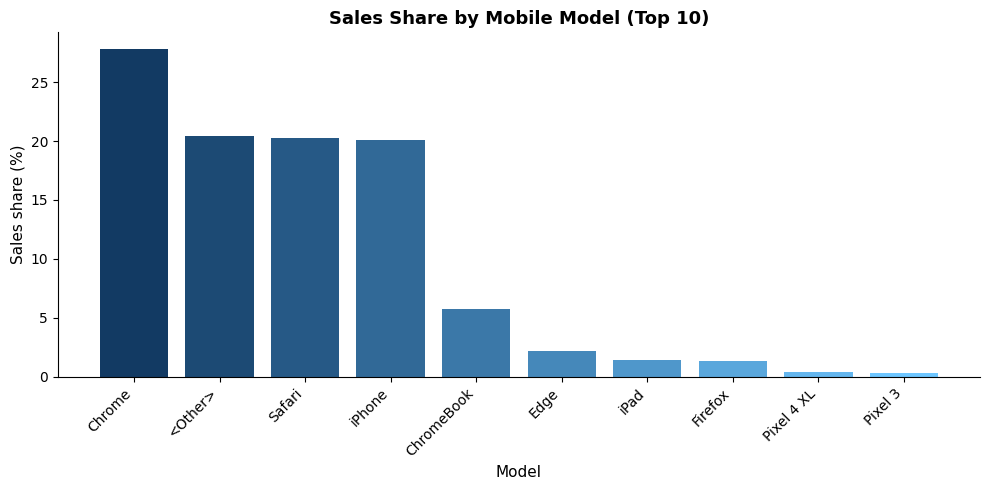

In [12]:
# This cell shows the top 10 device models by sales share (percentage).
model_sales = (
    df.groupby("mobile_model_name")["sales"]
      .sum()
      .sort_values(ascending=False)
)

model_share_pct = (model_sales / total_sales * 100).round(2)

print("Top 10 mobile models by sales share (%):")
print(model_share_pct.head(10))

plot_bar_gradient(model_share_pct, "Sales Share by Mobile Model (Top 10)", "Model", "Sales share (%)", top_n=10)

Top 10 traffic sources by sales share (%):
traffic_source_info
(organic) / organic                34.20
(direct) / (none)                  23.44
(referral) / referral              17.65
<Other> / <Other>                  14.05
(data deleted) / (data deleted)     6.26
<Other> / cpc                       4.27
<Other> / (data deleted)            0.12
Name: sales, dtype: float64


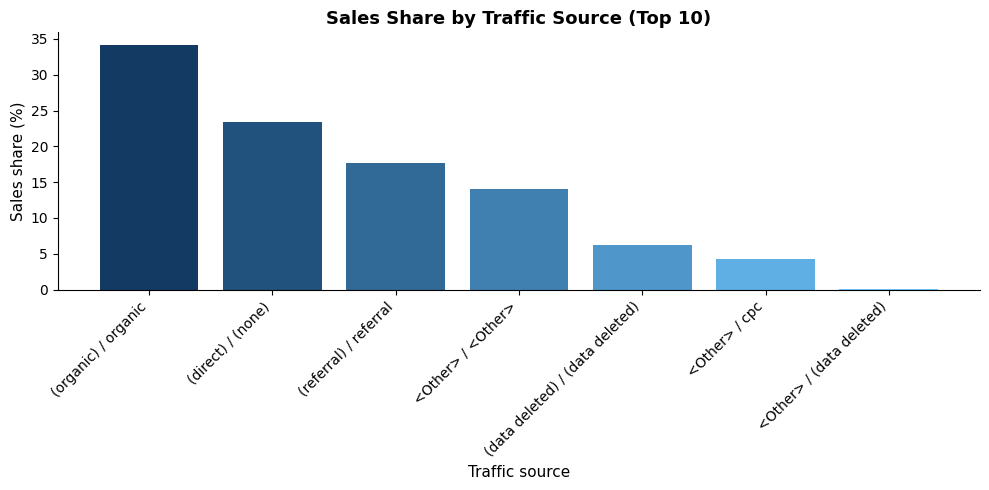

In [13]:
# This chart shows the top 10 traffic sources (source/medium) by sales share (%).
source_sales = df.groupby("traffic_source_info")["sales"].sum().sort_values(ascending=False)
source_share_pct = (source_sales / total_sales * 100).round(2)

print("Top 10 traffic sources by sales share (%):")
print(source_share_pct.head(10))

plot_bar_gradient(
    source_share_pct,
    "Sales Share by Traffic Source (Top 10)",
    "Traffic source",
    "Sales share (%)",
    top_n=10
)

Top 10 traffic sources by sales share (%):
traffic_source_info
(organic) / organic                34.20
(direct) / (none)                  23.44
(referral) / referral              17.65
<Other> / <Other>                  14.05
(data deleted) / (data deleted)     6.26
<Other> / cpc                       4.27
<Other> / (data deleted)            0.12
Name: sales, dtype: float64


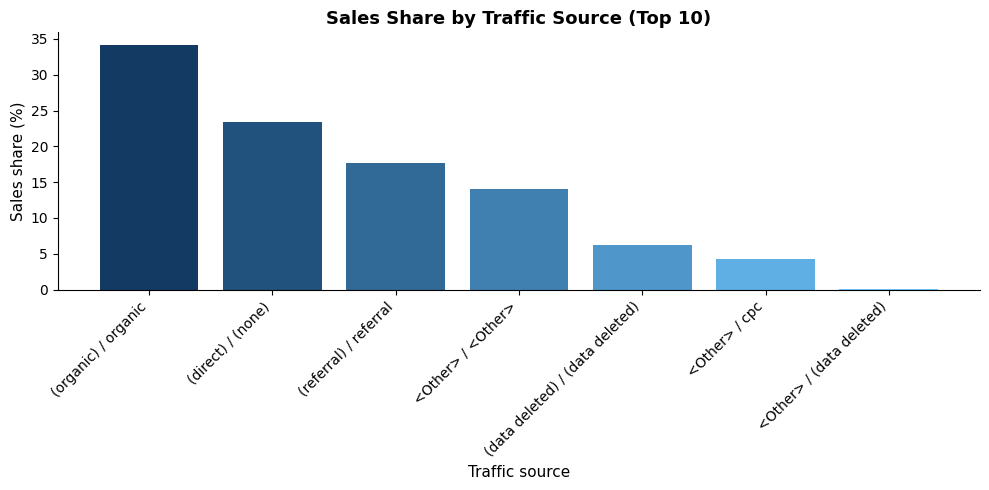

In [14]:
# This cell shows the top 10 traffic sources (source/medium) by sales share (percentage).
source_sales = (
    df.groupby("traffic_source_info")["sales"]
      .sum()
      .sort_values(ascending=False)
)

source_share_pct = (source_sales / total_sales * 100).round(2)

print("Top 10 traffic sources by sales share (%):")
print(source_share_pct.head(10))

plot_bar_gradient(source_share_pct, "Sales Share by Traffic Source (Top 10)", "Traffic source", "Sales share (%)", top_n=10)

In [15]:
# This cell helps you write a short conclusion for the mix analysis section.
top_device = device_sales.index[0]

channel_sales = df.groupby("traffic_channel")["sales"].sum().sort_values(ascending=False)
top_channel = channel_sales.index[0]

print("Conclusion notes:")
print(f"- The largest share of sales comes from the '{top_device}' device segment.")
print(f"- The leading traffic channel by sales is '{top_channel}'.")
print("- Next, I will analyse registered users (verification/unsubscribe) and compare groups statistically.")

Conclusion notes:
- The largest share of sales comes from the 'desktop' device segment.
- The leading traffic channel by sales is 'Organic Search'.
- Next, I will analyse registered users (verification/unsubscribe) and compare groups statistically.


In [16]:
# This cell creates a subset for registered users only (account_id is not null).
df_reg = df[df["account_id"].notna()].copy()
print("Registered rows:", len(df_reg))
print("Total rows:", len(df))

Registered rows: 2781
Total rows: 33538


In [17]:
# This cell shows key percentages for registered users: verified and unsubscribed.
verified_pct = df_reg["is_verified"].mean() * 100
unsub_pct = df_reg["is_unsubscribed"].mean() * 100

print(f"Verified users (% of registered): {verified_pct:.2f}%")
print(f"Unsubscribed users (% of registered): {unsub_pct:.2f}%")

Verified users (% of registered): 71.52%
Unsubscribed users (% of registered): 16.07%


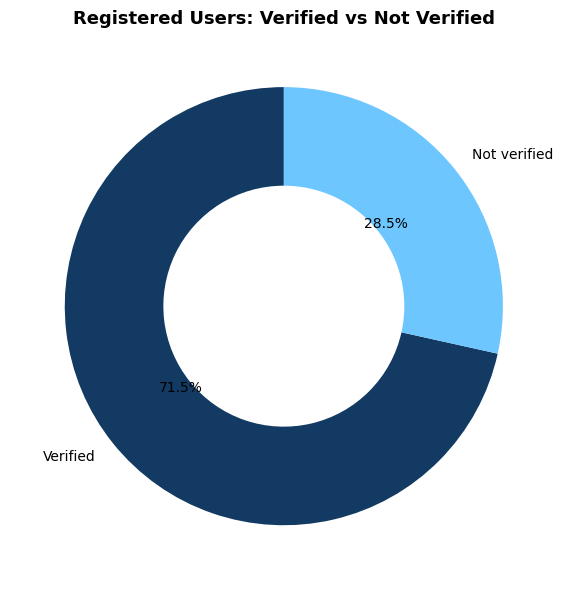

In [18]:
# This chart shows the split of registered users: verified vs not verified.
verified_counts = df_reg["is_verified"].value_counts().sort_index()
verified_counts.index = ["Not verified" if x == 0 else "Verified" for x in verified_counts.index]

plot_donut(verified_counts, "Registered Users: Verified vs Not Verified", top_n=2)

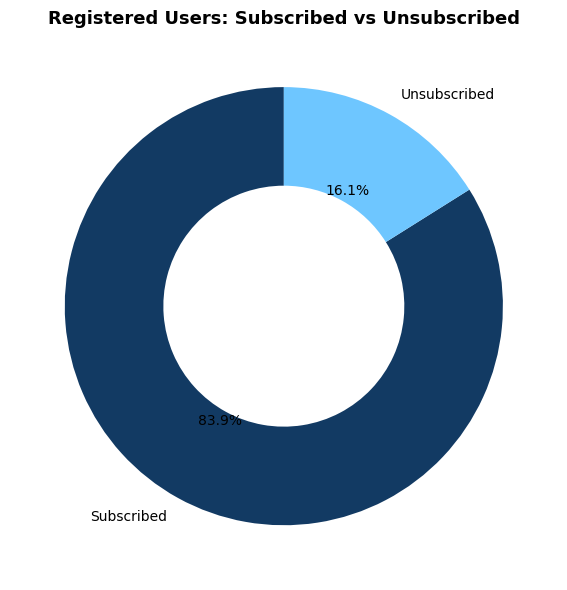

In [19]:
# This chart shows the split of registered users: subscribed vs unsubscribed.
sub_counts = df_reg["is_unsubscribed"].value_counts().sort_index()
sub_counts.index = ["Subscribed" if x == 0 else "Unsubscribed" for x in sub_counts.index]

plot_donut(sub_counts, "Registered Users: Subscribed vs Unsubscribed", top_n=2)

In [20]:
# This cell compares sales per session between subscribed and unsubscribed registered users.
# Metric: total sales per ga_session_id within each group.

# sales per session for registered users
sales_per_session = df_reg.groupby(["ga_session_id", "is_unsubscribed"])["sales"].sum().reset_index()

subscribed_sales = sales_per_session[sales_per_session["is_unsubscribed"] == 0]["sales"]
unsubscribed_sales = sales_per_session[sales_per_session["is_unsubscribed"] == 1]["sales"]

print("Subscribed sessions:", subscribed_sales.shape[0])
print("Unsubscribed sessions:", unsubscribed_sales.shape[0])
print("Median sales/session (Subscribed):", subscribed_sales.median())
print("Median sales/session (Unsubscribed):", unsubscribed_sales.median())

Subscribed sessions: 2334
Unsubscribed sessions: 447
Median sales/session (Subscribed): 395.0
Median sales/session (Unsubscribed): 450.0


/tmp/ipykernel_22112/2563273221.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, showfliers=False, patch_artist=True)


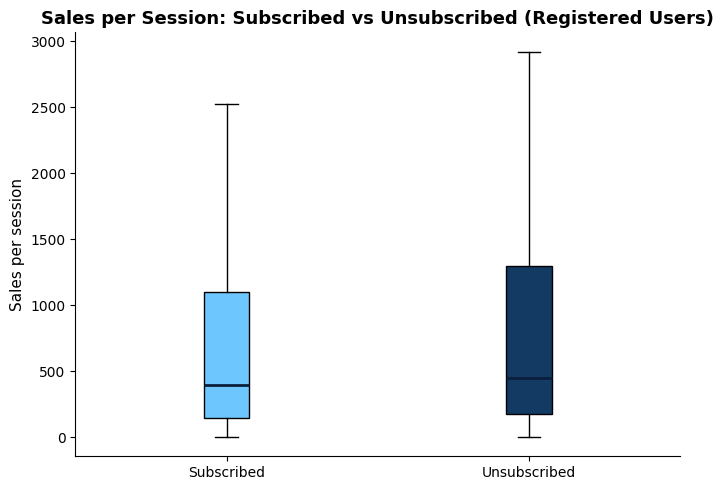

In [21]:
# This chart shows the distribution of sales per session for subscribed vs unsubscribed users (boxplot).
import matplotlib.pyplot as plt

data = [subscribed_sales.values, unsubscribed_sales.values]
labels = ["Subscribed", "Unsubscribed"]

plt.figure(figsize=(7, 5))
bp = plt.boxplot(data, labels=labels, showfliers=False, patch_artist=True)

# Simple navy styling (no grid)
colors = ["#6EC6FF", "#123A63"]  # light blue, lighter navy
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
for median in bp["medians"]:
    median.set_color("#0B1F3B")
    median.set_linewidth(2)

plt.title("Sales per Session: Subscribed vs Unsubscribed (Registered Users)")
plt.ylabel("Sales per session")
plt.tight_layout()
plt.show()

Top 10 countries by number of registered users:
country
United States     1207
India              246
Canada             207
United Kingdom      88
France              56
Germany             56
Taiwan              51
Spain               48
China               48
Singapore           44
Name: account_id, dtype: int64


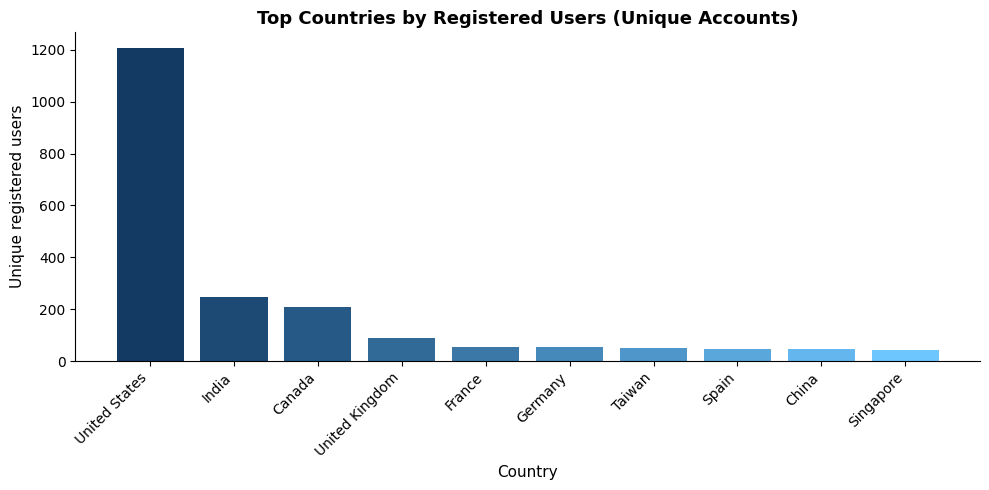

In [22]:
# This chart shows which countries have the most registered users (unique account_id).
reg_users_by_country = (
    df_reg.groupby("country")["account_id"]
          .nunique()
          .sort_values(ascending=False)
)

print("Top 10 countries by number of registered users:")
print(reg_users_by_country.head(10))

plot_bar_gradient(
    reg_users_by_country,
    "Top Countries by Registered Users (Unique Accounts)",
    "Country",
    "Unique registered users",
    top_n=10
)

In [23]:
# This cell prints a short conclusion template for the registered users section.
print("Conclusion notes:")
print(f"- Verified rate among registered users is {verified_pct:.1f}%.")
print(f"- Unsubscribe rate among registered users is {unsub_pct:.1f}%.")
print("- The boxplot suggests whether unsubscribed users have higher/lower sales per session (to be tested statistically later).")

Conclusion notes:
- Verified rate among registered users is 71.5%.
- Unsubscribe rate among registered users is 16.1%.
- The boxplot suggests whether unsubscribed users have higher/lower sales per session (to be tested statistically later).


Daily sales (first 5 rows):
order_date
2020-11-01    244292.5
2020-11-02    355506.8
2020-11-03    498979.6
2020-11-04    339187.1
2020-11-05    391276.6
Name: sales, dtype: float64


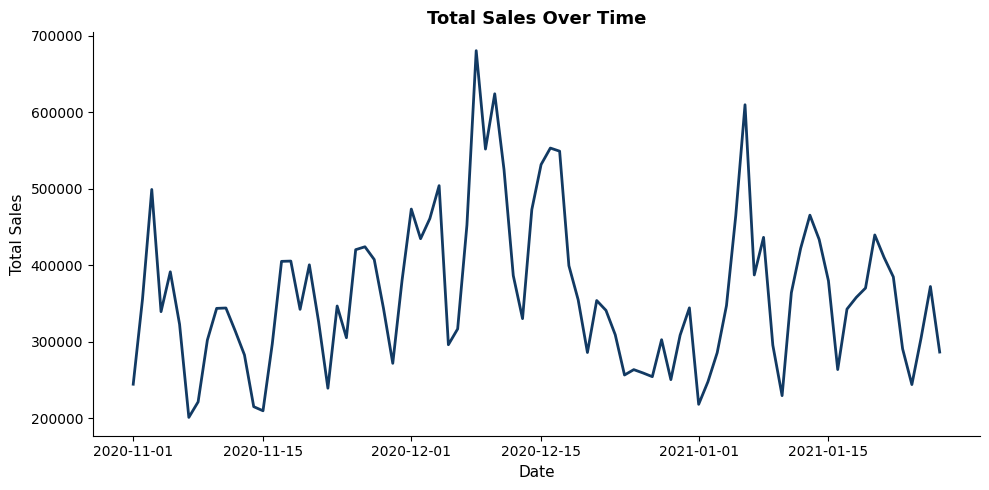

In [24]:
# This cell aggregates total sales by date to create a base daily time series.
daily_sales = df.groupby("order_date")["sales"].sum().sort_index()

print("Daily sales (first 5 rows):")
print(daily_sales.head())

plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, color="#123A63", linewidth=2)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

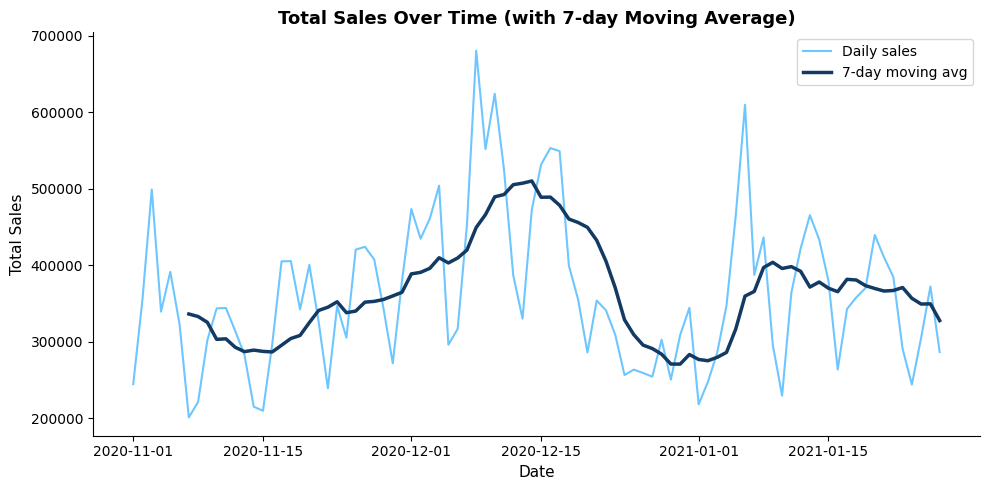

In [25]:
# This cell adds a 7-day moving average to highlight the overall trend and reduce noise.
daily_sales_ma7 = daily_sales.rolling(7).mean()

plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, color="#6EC6FF", linewidth=1.5, label="Daily sales")
plt.plot(daily_sales_ma7.index, daily_sales_ma7.values, color="#123A63", linewidth=2.5, label="7-day moving avg")
plt.title("Total Sales Over Time (with 7-day Moving Average)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

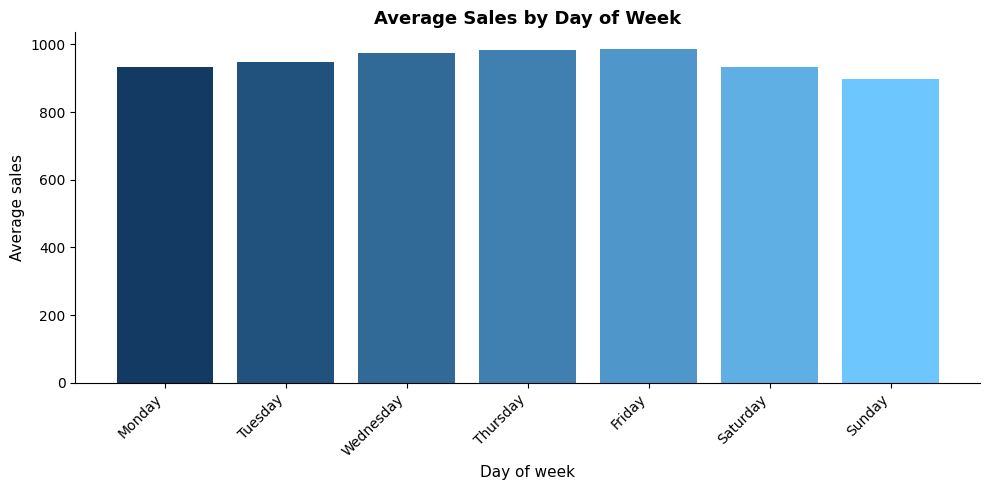

In [26]:
# This chart checks weekly seasonality by comparing average sales by day of week.
tmp = df.copy()
tmp["day_name"] = tmp["order_date"].dt.day_name()

dow_sales = tmp.groupby("day_name")["sales"].mean()

# Keep weekday order
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_sales = dow_sales.reindex(weekday_order)

plot_bar_gradient(dow_sales, "Average Sales by Day of Week", "Day of week", "Average sales", top_n=7)

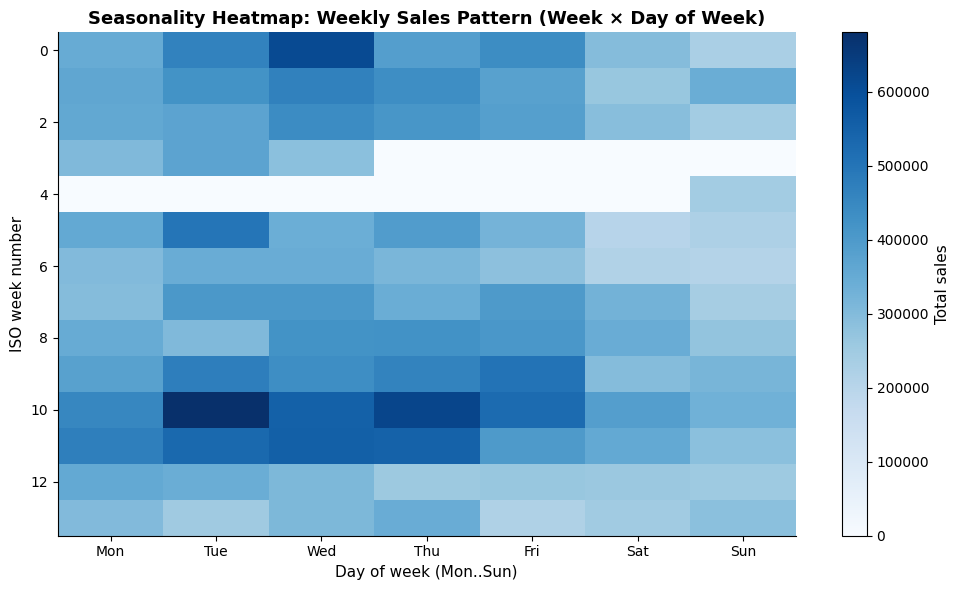

In [27]:
# This heatmap shows seasonality patterns: average daily sales by day of week and week number.
import numpy as np

tmp = df.copy()
tmp["day_of_week"] = tmp["order_date"].dt.dayofweek  # 0=Mon
tmp["week"] = tmp["order_date"].dt.isocalendar().week.astype(int)

heat = tmp.groupby(["week", "day_of_week"])["sales"].sum().reset_index()
pivot = heat.pivot(index="week", columns="day_of_week", values="sales").fillna(0)

plt.figure(figsize=(10, 6))
plt.imshow(pivot.values, aspect="auto", cmap="Blues")  # navy/blue feel
plt.title("Seasonality Heatmap: Weekly Sales Pattern (Week × Day of Week)")
plt.xlabel("Day of week (Mon..Sun)")
plt.ylabel("ISO week number")

plt.xticks(ticks=range(7), labels=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.colorbar(label="Total sales")
plt.tight_layout()
plt.show()

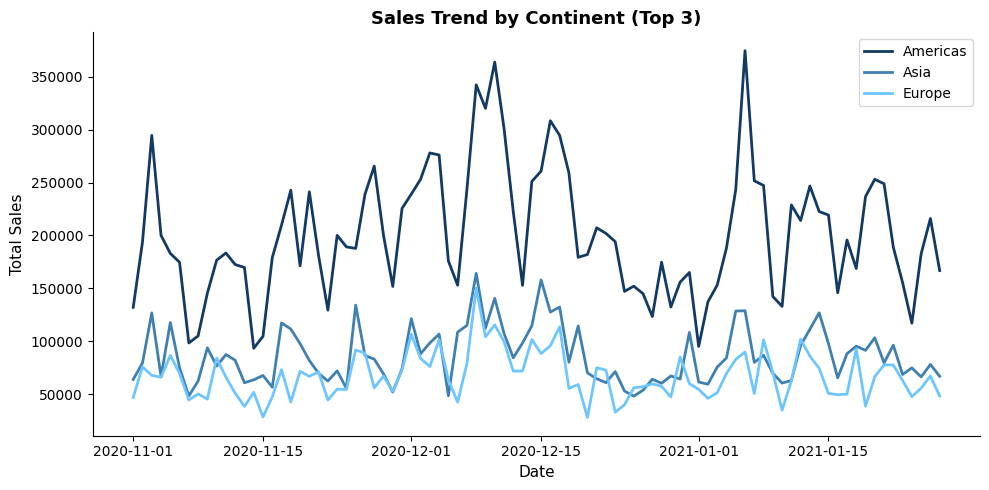

In [28]:
# This chart compares sales trends for the top 3 continents by total sales.
top3_continents = (
    df.groupby("continent")["sales"].sum().sort_values(ascending=False).head(3).index.tolist()
)

df_top3 = df[df["continent"].isin(top3_continents)]

daily_continent = (
    df_top3.groupby(["order_date", "continent"])["sales"].sum().reset_index()
)

pivot_continent = daily_continent.pivot(index="order_date", columns="continent", values="sales").fillna(0)

plot_lines(pivot_continent, "Sales Trend by Continent (Top 3)", "Date", "Total Sales")

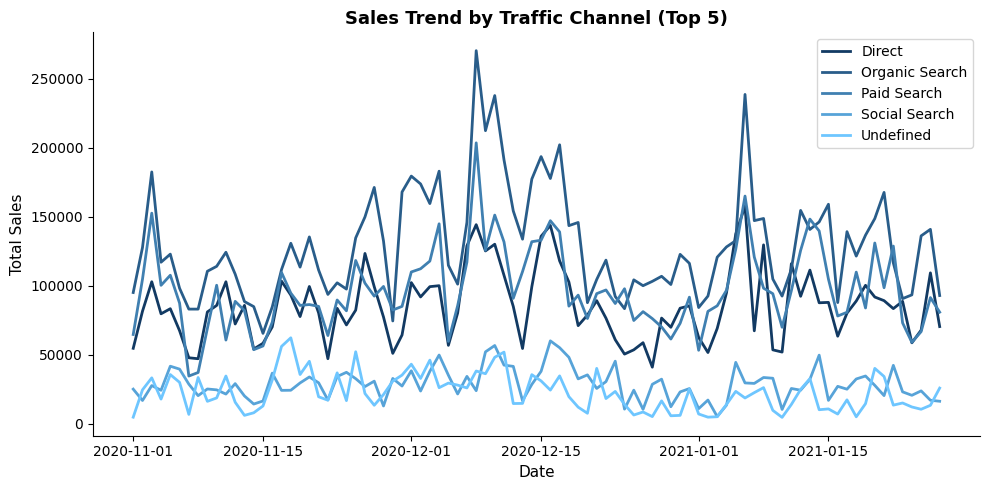

In [29]:
# This chart compares sales trends for the top 5 traffic channels by total sales.
top5_channels = (
    df.groupby("traffic_channel")["sales"].sum().sort_values(ascending=False).head(5).index.tolist()
)

df_top5_ch = df[df["traffic_channel"].isin(top5_channels)]

daily_channel = (
    df_top5_ch.groupby(["order_date", "traffic_channel"])["sales"].sum().reset_index()
)

pivot_channel = daily_channel.pivot(index="order_date", columns="traffic_channel", values="sales").fillna(0)

plot_lines(pivot_channel, "Sales Trend by Traffic Channel (Top 5)", "Date", "Total Sales")

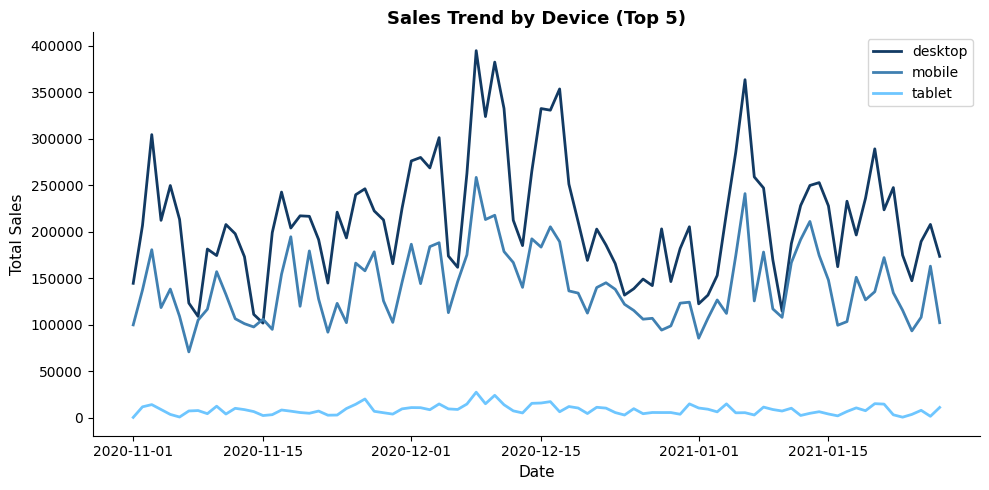

In [30]:
# This chart compares sales trends for the top 5 devices by total sales.
top5_devices = (
    df.groupby("device")["sales"].sum().sort_values(ascending=False).head(5).index.tolist()
)

df_top5_dev = df[df["device"].isin(top5_devices)]

daily_device = (
    df_top5_dev.groupby(["order_date", "device"])["sales"].sum().reset_index()
)

pivot_device = daily_device.pivot(index="order_date", columns="device", values="sales").fillna(0)

plot_lines(pivot_device, "Sales Trend by Device (Top 5)", "Date", "Total Sales")

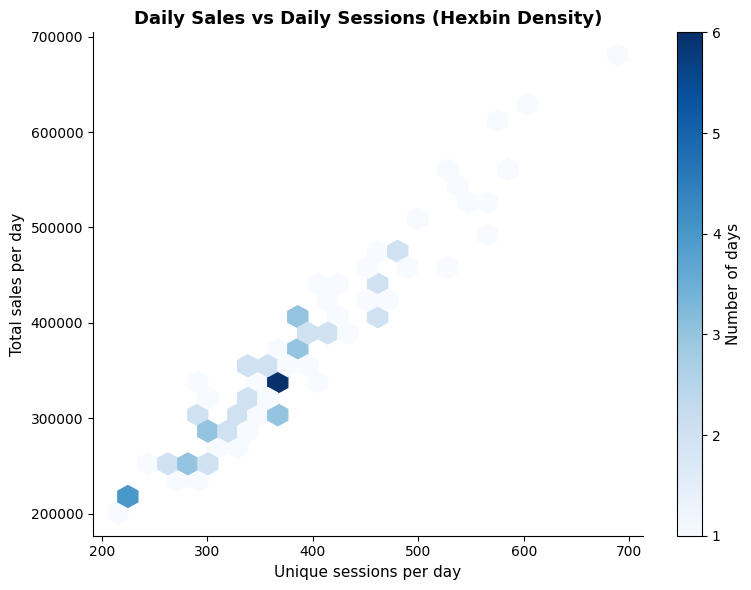

In [31]:
# This plot shows the relationship between daily sessions and daily sales using a hexbin (density scatter).

daily = df.groupby("order_date").agg(
    total_sales=("sales", "sum"),
    sessions=("ga_session_id", "nunique")
).reset_index()

plt.figure(figsize=(8, 6))
plt.hexbin(daily["sessions"], daily["total_sales"], gridsize=25, cmap="Blues", mincnt=1)
plt.colorbar(label="Number of days")
plt.title("Daily Sales vs Daily Sessions (Hexbin Density)")
plt.xlabel("Unique sessions per day")
plt.ylabel("Total sales per day")
plt.tight_layout()
plt.show()

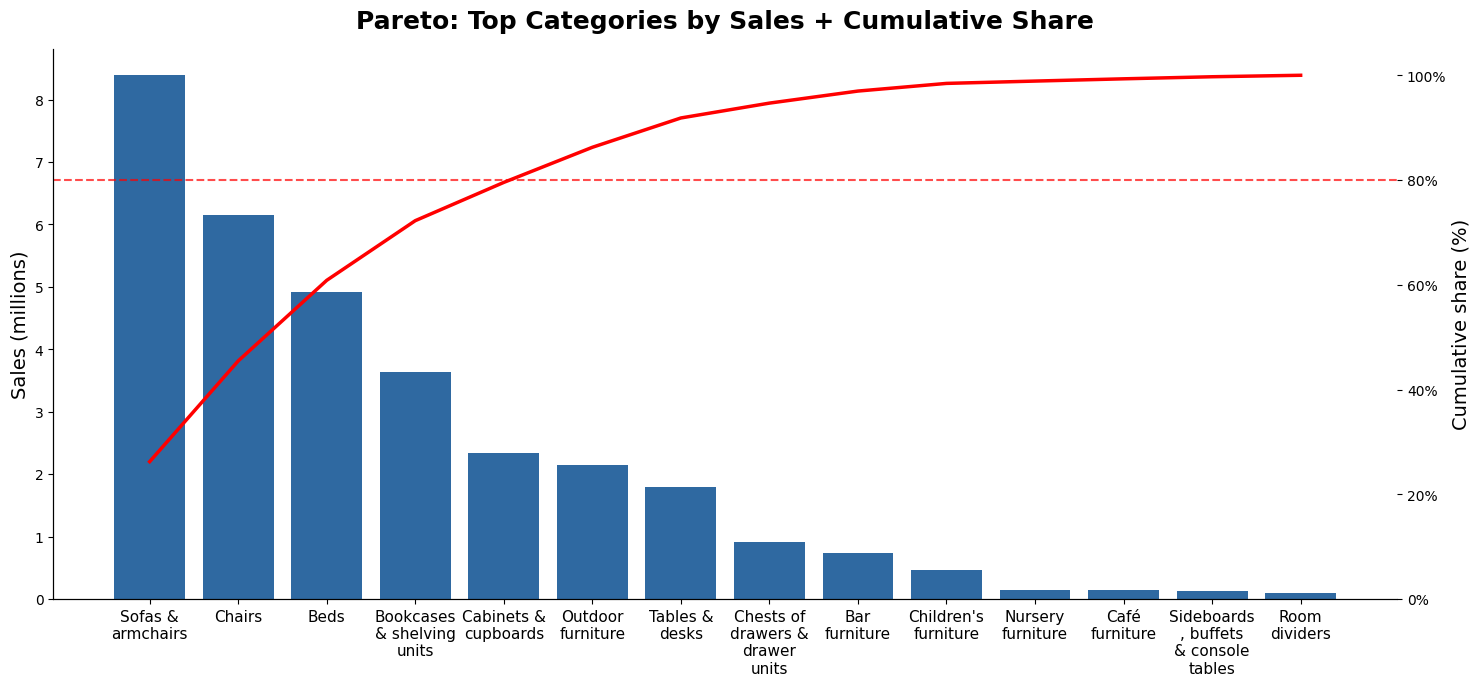

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import textwrap

# total sales by category
cat_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)
cat_sales_top = cat_sales.head(15)

# cumulative share
cum_share = (cat_sales_top.cumsum() / cat_sales.sum()) * 100

# wrap labels more tightly
labels = ['\n'.join(textwrap.wrap(str(x), width=10)) for x in cat_sales_top.index]

# bigger figure ONLY for this chart
fig, ax1 = plt.subplots(figsize=(16, 10))

# bars in one solid colour (no gradient)
ax1.bar(range(len(labels)), cat_sales_top.values / 1_000_000, color="#2F69A1")

ax1.set_ylabel("Sales (millions)", fontsize=14)
ax1.set_title("Pareto: Top Categories by Sales + Cumulative Share", pad=15, fontsize=18)

# x-axis labels
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=0, ha="center", fontsize=11)

# cumulative line
ax2 = ax1.twinx()
ax2.plot(range(len(labels)), cum_share.values, color="red", linewidth=2.5)
ax2.set_ylabel("Cumulative share (%)", fontsize=14)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 105)

# 80% reference line
ax2.axhline(80, color="red", linestyle="--", linewidth=1.5, alpha=0.7)

# extra spacing only for this plot
plt.subplots_adjust(bottom=0.35, left=0.08, right=0.92, top=0.90)

plt.show()

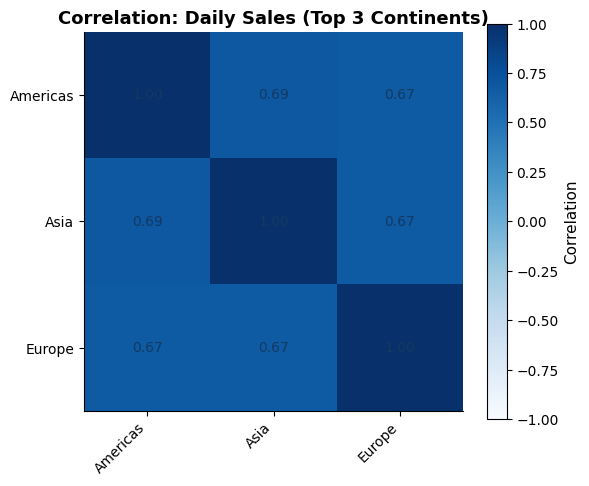

In [33]:
# This heatmap shows correlations between daily sales of the top 3 continents (no seaborn).
import matplotlib.pyplot as plt
import numpy as np

top3 = df.groupby("continent")["sales"].sum().sort_values(ascending=False).head(3).index.tolist()
tmp = df[df["continent"].isin(top3)]

daily_cont = (
    tmp.groupby(["order_date", "continent"])["sales"].sum()
       .reset_index()
       .pivot(index="order_date", columns="continent", values="sales")
       .fillna(0)
)

corr = daily_cont.corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr.values, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation: Daily Sales (Top 3 Continents)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")

# add numbers
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", color="#123A63")

plt.tight_layout()
plt.show()

**Top markets by sales.**
Sales are highly concentrated in the Americas, which is the clear leader by total revenue. The top three continents by sales are Americas (17.67M), Asia (7.60M) and Europe (5.93M). At country level, the United States (13.94M) is the main market, followed by India (2.81M) and Canada (~2.44M).

**Top markets by order proxy (sessions).**
Using unique sessions as a proxy for orders, the pattern is consistent: the Americas (18,553 sessions) lead by a wide margin, followed by Asia (7,950) and Europe (6,261). The United States (14,673 sessions) also leads by volume, with India and Canada as the next largest markets.

**Category performance.**
Revenue is driven mainly by a small number of categories. The top categories by total sales are Sofas & armchairs, Chairs, and Beds, which suggests that large furniture items contribute a major share of overall revenue.

**Device mix.**
Most sales come from desktop (59.0%), with mobile (38.73%) as a strong second channel. Tablet (2.26%) contributes only a small share, so optimisation efforts should prioritise desktop and mobile experiences.

**Traffic mix.**
The largest traffic source by sales share is (organic) / organic (34.2%), followed by (direct) / (none) (23.44%) and (referral) / referral (17.65%). This indicates that SEO and brand/direct demand are key revenue drivers, while referrals also play a meaningful supporting role.

**Registration coverage.**
Only a small share of rows is linked to registered accounts (2,781 registered rows vs 30,757 guest rows), so user-status metrics should be interpreted only within the registered subset.

**Verified and unsubscribe rates.**
Among registered users, 71.52% have verified their email. The unsubscribe rate is 16.07%, which means most registered users remain subscribed.

**Subscribed vs unsubscribed behaviour (sales per session).**
Median sales per session are slightly higher for unsubscribed users (450) than for subscribed users (395). This suggests unsubscribed users may still purchase, but potentially engage differently with email over time. A statistical test is recommended later to confirm whether this difference is significant.

**Where registered users are concentrated.**
Registered users are mostly concentrated in the United States (1,207), with smaller clusters in India (246) and Canada (207), which broadly matches the overall sales concentration by geography.

**Overall trend.**
Daily sales show clear day-to-day fluctuations across the period (2020-11-01 to 2021-01-27). The 7-day moving average is useful for separating short-term noise from the underlying trend.

**Seasonality.**
The day-of-week analysis and the heatmap provide a quick way to spot repeating weekly patterns. If consistent peaks appear on specific weekdays, it may indicate a stable behavioural cycle (e.g., weekend browsing vs weekday purchasing).

**Segment trends.**
When broken down by continent, traffic channel, and device, the time series allow you to see whether growth (or declines) is driven by specific segments rather than the whole market. This makes it easier to focus optimisation efforts on the segments that actually move the total.



In [34]:
# This code exports the dataset to an Excel file.
df.to_excel("portfolio_dataset.xlsx", index=False)
print("Saved: portfolio_dataset.xlsx")

Saved: portfolio_dataset.xlsx


In [35]:
df.to_csv("portfolio_dataset.csv", index=False)